In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors, patches
from matplotlib.patches import Patch
from typing import Dict, Generator, Iterable, List, Optional

import tspipe
from tspipe.scheduler import PipelineSchedule, schedule_start, new_schedule_start, new_schedule_repeat
from tspipe.prototype_scheduler import PipelineScheduleKD

### schedule_without_pipeline (the original code)

In [2]:
def schedule_without_pipeline(devices, batch_index, optimize_len, gpipe_num_ubatch=None) \
        -> Iterable[Iterable[Optional[PipelineSchedule]]]:
    # (i(microbatch idx), j(gpu idx), prev_partition, is_target, batch_idx, view_idx, dependencies, model_update_ver, backprop)

    num_devices = devices
    # num_batches = int((3 * (num_devices - 1) - optimize_len) / 2)
    if gpipe_num_ubatch is not None:
        num_batches = gpipe_num_ubatch
    else:
        num_batches = num_devices - 1

    schedule = []
    micro_idx = [0 for i in range(num_devices)] # current microbatch index
    is_target = [0 for i in range(num_devices)] # Count of microbatches processed to determine if view is teacher/student. from 0 to 4 * num_batches each value
    view_idx = [0 for i in range(num_devices)]  # current view index from 0 to 2 * num_batches
    forward = [True for i in range(num_devices)] # forward or backward bool

    # Forward
    for bat_id in range(4 * num_batches + (num_devices - 1)):
        sched = []
        for dev_id in range(num_devices):
            if micro_idx[dev_id] >= num_batches: 					# if microbatch index is greater than num_batches
                micro_idx[dev_id] -= num_batches 						# reset
            prev = dev_id - 1 if dev_id > 0 else None 				# from what device the data is coming
            if is_target[dev_id] >= num_batches * 4: 				# if is_target is greater than 4 * num_batches
                is_target[dev_id] -= 4 * num_batches					# reset
                forward[dev_id] = False 							# set forward to False for backward pass
            is_target_bool = is_target[dev_id] < 2 * num_batches 	# [Role switch] if is_target is less than 2 * num_batches is_target_bool is True else False
            if view_idx[dev_id] >= num_batches * 2: 				# if view index is greater than 2 * num_batches
                view_idx[dev_id] -= 2 * num_batches 					# reset
            view_idx_int = 1 if view_idx[dev_id] >= num_batches else 0 # [Role switch] if view index is greater than num_batches
            if micro_idx[dev_id] == 0 and view_idx_int == 0: 		# if microbatch index is 0 and view index is 0
                model_update_ver = batch_index - 1						# model_update_ver used to trigger model version copying or syncing only once per batch, one device
            else:														# set model update version to batch index - 1
                model_update_ver = None								# else set model update version to None

            if dev_id <= bat_id and forward[dev_id]:
                #            (i,         j,     prev_partition, is_target,      batch_idx,   view_idx, dependencies, model_update_ver, backprop, optimize) # noqa :E203
                block = tuple([micro_idx[dev_id], dev_id, prev, is_target_bool, batch_index, view_idx_int, None, model_update_ver, False, False]) # noqa :E203

                micro_idx[dev_id] = micro_idx[dev_id] + 1
                view_idx[dev_id] = view_idx[dev_id] + 1
                is_target[dev_id] = is_target[dev_id] + 1
            else:
                block = None
            sched.append(PipelineSchedule(block) if block is not None else None)
        schedule.append(sched)
    grad_micro_idx = [num_batches - 1 for i in range(num_devices)] 		# Tracks backward microbatch index
    grad_view_idx = [num_batches * 2 - 1 for i in range(num_devices)] 	# Determines when to optimize. current view index from 0 to 2 * num_batches
    backward_start = num_devices - 1

    # Backward
    for bat_id in range(2 * num_batches + (num_devices - 1) + 1):
        sched = []
        for dev_id in range(num_devices):
            if grad_micro_idx[dev_id] < 0: 
                grad_micro_idx[dev_id] += num_batches # why reset to num_batches - 1?
            prev = dev_id + 1 if dev_id < num_devices - 1 else None
            grad_view_idx_int = 1 if grad_view_idx[dev_id] >= num_batches else 0
            
            if dev_id >= backward_start and grad_view_idx[dev_id] >= 0:
                block = tuple([grad_micro_idx[dev_id], dev_id, prev, False, batch_index,
                               grad_view_idx_int, None, None, True, False])
                grad_micro_idx[dev_id] = grad_micro_idx[dev_id] - 1
                grad_view_idx[dev_id] = grad_view_idx[dev_id] - 1
            else:
                if grad_view_idx[dev_id] == -1: # reach the end of the backward pass is optimization
                    block = tuple([0, dev_id, None, False, batch_index, 0, None, None, False, True])
                    grad_view_idx[dev_id] -= 1
                else:
                    block = None
            sched.append(PipelineSchedule(block) if block is not None else None)
        schedule.append(sched)
        backward_start -= 1
    return schedule

### schedule_without_pipeline_kd

In [3]:
def schedule_without_pipeline_kd(devices, batch_index, optimize_len, gpipe_num_ubatch=None) \
        -> Iterable[Iterable[Optional[PipelineScheduleKD]]]:
    # (i, j, prev_partition, is_target, batch_idx, view_idx, dependencies, model_update_ver, backprop)

    num_devices = devices
    num_ubatch = gpipe_num_ubatch if gpipe_num_ubatch is not None else num_devices - 1

    schedule = []
    micro_idx = [0 for _ in range(num_devices)]		# current microbatch index (0 to num_ubatch-1)
    is_target = [0 for _ in range(num_devices)]		# Count of microbatches processed to determine if view is teacher/student. from 0 to 2*num_ubatch each value
    forward = [True for _ in range(num_devices)]	# forward active flag
    
    # Forward
    for bat_id in range(2 * num_ubatch + (num_devices - 1)):
        sched = []
        for dev_id in range(num_devices):
            if micro_idx[dev_id] >= num_ubatch:
                micro_idx[dev_id] -= num_ubatch # keeps micro index in range (0 to num_ubatch-1)
                
            prev = dev_id - 1 if dev_id > 0 else None
            
            if is_target[dev_id] >= num_ubatch * 2:
                is_target[dev_id] -= 2 * num_ubatch
                forward[dev_id] = False
            is_target_bool = is_target[dev_id] < num_ubatch
            
            if micro_idx[dev_id] == 0 and is_target[dev_id] == 0:
                model_update_ver = batch_index - 1
            else:
                model_update_ver = None
            if dev_id <= bat_id and forward[dev_id]:
                #            (i,         j,     prev_partition, is_target,      batch_idx,   view_idx, dependencies, model_update_ver, backprop, optimize) # noqa :E203
                block = tuple([micro_idx[dev_id], dev_id, prev, is_target_bool, batch_index, 0, None, model_update_ver, False, False]) # noqa :E203

                micro_idx[dev_id] += 1
                is_target[dev_id] += 1
            else:
                block = None
            sched.append(PipelineScheduleKD(block) if block is not None else None)
        schedule.append(sched)
    
    grad_micro_idx = [num_ubatch - 1 for _ in range(num_devices)]
    backward_start = num_devices - 1

    # Backward
    for bat_id in range(num_ubatch + (num_devices - 1) + 1):
        sched = []
        for dev_id in range(num_devices):
            prev = dev_id + 1 if dev_id < num_devices - 1 else None

            if dev_id >= backward_start and grad_micro_idx[dev_id] >= 0:
                block = tuple([grad_micro_idx[dev_id], dev_id, prev, False, batch_index,
                               0, None, None, True, False])
                grad_micro_idx[dev_id] -= 1
            elif grad_micro_idx[dev_id] == -1: # reach the end of the backward pass is optimization
                block = tuple([0, dev_id, None, False, batch_index, 0, None, None, False, True])
                grad_micro_idx[dev_id] -= 1
            else:
                block = None
            sched.append(PipelineScheduleKD(block) if block is not None else None)
        schedule.append(sched)
        backward_start -= 1
    return schedule

### schedule_gpipe

In [4]:
def schedule_gpipe(devices, batch_index, optimize_len, gpipe_num_ubatch=None) \
        -> Iterable[Iterable[Optional[PipelineScheduleKD]]]:
    # (i, j, prev_partition, is_target, batch_idx, view_idx, dependencies, model_update_ver, backprop)

    num_devices = devices
    num_ubatch = gpipe_num_ubatch if gpipe_num_ubatch is not None else num_devices - 1

    schedule = []
    micro_idx = [0 for _ in range(num_devices)]		# current microbatch index (0 to num_ubatch-1)
    is_target = [0 for _ in range(num_devices)]		# Count of microbatches processed to determine if view is teacher/student. from 0 to 2*num_ubatch each value
    forward = [True for _ in range(num_devices)]	# forward active flag
    
    # Forward
    for bat_id in range(2 * num_ubatch + (num_devices - 1)):
        sched = []
        for dev_id in range(num_devices):
            if micro_idx[dev_id] >= num_ubatch:
                micro_idx[dev_id] -= num_ubatch # keeps micro index in range (0 to num_ubatch-1)
                
            prev = dev_id - 1 if dev_id > 0 else None
            
            if is_target[dev_id] >= num_ubatch * 2:
                is_target[dev_id] -= 2 * num_ubatch
                forward[dev_id] = False
            is_target_bool = is_target[dev_id] < num_ubatch
            
            if micro_idx[dev_id] == 0 and is_target[dev_id] == 0:
                model_update_ver = batch_index - 1
            else:
                model_update_ver = None
            if dev_id <= bat_id and forward[dev_id]:
                #            (i,         j,     prev_partition, is_target,      batch_idx,   view_idx, dependencies, model_update_ver, backprop, optimize) # noqa :E203
                block = tuple([micro_idx[dev_id], dev_id, prev, is_target_bool, batch_index, 0, None, model_update_ver, False, False]) # noqa :E203

                micro_idx[dev_id] += 1
                is_target[dev_id] += 1
            else:
                block = None
            sched.append(PipelineScheduleKD(block) if block is not None else None)
        schedule.append(sched)
    
    grad_micro_idx = [num_ubatch - 1 for _ in range(num_devices)]
    backward_start = num_devices - 1

    # Backward
    for bat_id in range(num_ubatch + (num_devices - 1)):
        sched = []
        for dev_id in range(num_devices):
            prev = dev_id + 1 if dev_id < num_devices - 1 else None

            if dev_id >= backward_start and grad_micro_idx[dev_id] >= 0:
                block = tuple([grad_micro_idx[dev_id], dev_id, prev, False, batch_index,
                               0, None, None, True, False])
                grad_micro_idx[dev_id] -= 1
            elif grad_micro_idx[dev_id] == -1: # reach the end of the backward pass is optimization
                block = None
                grad_micro_idx[dev_id] -= 1
            else:
                block = None
            sched.append(PipelineScheduleKD(block) if block is not None else None)
        schedule.append(sched)
        backward_start -= 1
    
    # Optimization
    optim_sched = []
    for dev_id in range(num_devices):
        block = tuple([0, dev_id, None, False, batch_index, 0, None, None, False, True])
        optim_sched.append(PipelineScheduleKD(block))
    schedule.append(optim_sched)
    return schedule

### schedule_start_kd

In [5]:
# micro_idx = [0 for i in range(num_devices)] # current microbatch index
# is_target = [0 for i in range(num_devices)] # Count of microbatches processed to determine if view is teacher/student. from 0 to 4 * num_ubatch each value
# view_idx = [0 for i in range(num_devices)]  # current view index from 0 to 2 * num_ubatch

def schedule_start_kd(devices, batch_index, micro_idx, is_target, view_idx, optimize_len, skip=False, num_ubatch=6) \
        -> Iterable[Iterable[Optional[PipelineScheduleKD]]]:
    num_devices = devices
    start = []

    for bat_id in range(num_ubatch):
        schedule = []
        for dev_id in range(num_devices):

            if micro_idx[dev_id] >= num_ubatch:
                micro_idx[dev_id] -= num_ubatch

            prev = dev_id - 1 if dev_id > 0 else None

            if is_target[dev_id] >= num_ubatch * 2:
                is_target[dev_id] -= num_ubatch * 2

            if dev_id <= bat_id:
                block = tuple([micro_idx[dev_id], dev_id, prev, True, batch_index, 0, None,
                               None, False, False])
                micro_idx[dev_id] = micro_idx[dev_id] + 1
                is_target[dev_id] = is_target[dev_id] + 1
            else:
                block = None
            schedule.append(PipelineScheduleKD(block) if block is not None else None)
        start.append(schedule)
    return start

### new_schedule_start_kd

In [6]:
# micro_idx = [0 for i in range(num_devices)] # current microbatch index
# is_target = [0 for i in range(num_devices)] # Count of microbatches processed to determine if view is teacher/student. from 0 to 2 * num_ubatch each value

def new_schedule_start_kd(devices, batch_index, micro_idx, is_target, view_idx, 
                          optimize, batch_count, optimize_len, num_ubatch=6):
    num_devices = devices
    repeat = []

    backprop = [-1 for _ in range(num_devices)]
    propagate = [0 for _ in range(num_devices)]
    grad_micro_idx = [2 * num_ubatch - 1 for _ in range(num_devices)]

    for _ in range(4 * num_ubatch + optimize_len):
        schedule = []
        dependency = None
        
        for dev_id in range(num_devices):
            if backprop[dev_id] == -1: # Forward 단계 스케줄링 (해당 파티션이 아직 backward를 시작하지 않은 경우)

                if optimize[dev_id] > 0:
                    if optimize[dev_id] == optimize_len:
                        block = tuple([0, dev_id, 0, False, batch_index, 0, None, None, False, True])
                    optimize[dev_id] -= 1
                else:
                    if micro_idx[dev_id] >= num_ubatch:
                        micro_idx[dev_id] -= num_ubatch

                    prev = dev_id - 1 if dev_id > 0 else None

                    if is_target[dev_id] >= num_ubatch * 2:
                        is_target[dev_id] -= num_ubatch * 2
                    is_target_bool = is_target[dev_id] < num_ubatch

                    # Dependency. 마지막 파티션이 마지막 forward를 처리할 경우 dependency 설정 
                    if dev_id == num_devices - 1 and is_target[dev_id] == 2*num_ubatch - 1:
                        dependency = batch_index
                        backprop[dev_id] = 2*num_ubatch - 1 # (나중 backward 시작 시점)

                    # Model Update Version (tag the model state that was used for this forward pass )
                    if micro_idx[dev_id] == 0 and batch_count[dev_id] % num_ubatch == 0: # first microbatch of forward and start of the full pipeline cycle
                        model_update_ver = batch_index - 1
                    else:
                        model_update_ver = None

                    if batch_count[dev_id] >= num_ubatch:
                		#            (i,         j,     prev_partition, is_target,      batch_idx,   
                		#   	view_idx, dependencies, model_update_ver, backprop, optimize) # noqa :E203
                        block = tuple([micro_idx[dev_id], dev_id, prev, is_target_bool, batch_index + 1,
                                       0, dependency, model_update_ver, False, False])
                    else:
                        block = tuple([micro_idx[dev_id], dev_id, prev, is_target_bool, batch_index,
                                       0, dependency, model_update_ver, False, False])

                    micro_idx[dev_id] += 1
                    is_target[dev_id] += 1
                    batch_count[dev_id] += 1

                    if batch_count[dev_id] >= 2*num_ubatch and optimize[dev_id] == 0:
                        optimize[dev_id] = optimize_len
                        batch_count[dev_id] = 0
            else: # Backward 단계 스케줄링 (해당 파티션이 backward 단계에 들어간 경우)
                if grad_micro_idx[dev_id] < 0:
                    grad_micro_idx[dev_id] += num_ubatch

                prev = dev_id + 1 if dev_id < num_devices - 1 else None

                if dev_id > 0 and propagate[dev_id] < 1:
                    propagate[dev_id] += 1
                    if propagate[dev_id] == 1:
                        backprop[dev_id - 1] = 2*num_ubatch - 1

                block = tuple([grad_micro_idx[dev_id], dev_id, prev, False, batch_index,
                               0, None, None, True, False])

                backprop[dev_id] -= 1
                grad_micro_idx[dev_id] -= 1

            schedule.append(PipelineScheduleKD(block) if block is not None else None)
        repeat.append(schedule)
    return repeat # -> List[List[PipelineSchedule]]바깥 리스트: 각 clock (시간 스텝)


### new_schedule_repeat_kd

In [7]:
# micro_idx = [0 for i in range(num_devices)] # current microbatch index
# is_target = [0 for i in range(num_devices)] # Count of microbatches processed to determine if view is teacher/student. from 0 to 2 * num_ubatch each value

def new_schedule_repeat_kd(devices, batch_index, micro_idx, is_target, view_idx,
                        optimize, batch_count, optimize_len, num_ubatch=6):
    num_devices = devices
    repeat = []

    backprop = [-1 for _ in range(num_devices)]
    propagate = [0 for _ in range(num_devices)]
    grad_micro_idx = [2 * num_ubatch - 1 for i in range(num_devices)]
    reset = False
    
    for _ in range(4 * num_ubatch + optimize_len):
        schedule = []
        dependency = None
        
        for dev_id in range(num_devices):
            if backprop[dev_id] == -1:
                
                if optimize[dev_id] > 0:
                    if optimize[dev_id] == optimize_len:
                        if reset:
                            block = tuple([0, dev_id, 0, False, batch_index, 0, None, None, False, True])
                        else:
                            block = tuple([0, dev_id, 0, False, batch_index - 1, 0, None, None, False, True])
                    else:
                        block = None
                    optimize[dev_id] -= 1
                else:
                    if micro_idx[dev_id] >= num_ubatch:
                        micro_idx[dev_id] -= num_ubatch
                        if dev_id == num_devices - 1:
                            reset = True

                    # previous Partitions
                    prev = dev_id - 1 if dev_id > 0 else None

                    if is_target[dev_id] >= num_ubatch * 2:
                        is_target[dev_id] -= num_ubatch * 2
                    is_target_bool = is_target[dev_id] < num_ubatch

                    # Dependency
                    if dev_id == num_devices - 1 and is_target[dev_id] == 2 * num_ubatch - 1:
                        dependency = batch_index
                        backprop[dev_id] = 2*num_ubatch - 1

                    # Model Update Ver
                    if micro_idx[dev_id] == 0 and batch_count[dev_id] % num_ubatch == 0:
                        model_update_ver = batch_index - 1
                    else:
                        model_update_ver = None

                    if batch_count[dev_id] >= num_ubatch and reset:
                		#            (i,         j,     prev_partition, is_target,      batch_idx,   
                		#   	view_idx, dependencies, model_update_ver, backprop, optimize)
                        block = tuple([micro_idx[dev_id], dev_id, prev, is_target_bool, batch_index + 1,
                                       0, dependency, model_update_ver, False, False])
                    else:
                        block = tuple([micro_idx[dev_id], dev_id, prev, is_target_bool, batch_index,
                                       0, dependency, model_update_ver, False, False])

                    micro_idx[dev_id] += 1
                    is_target[dev_id] += 1
                    batch_count[dev_id] += 1

                    if batch_count[dev_id] >= 2*num_ubatch and optimize[dev_id] == 0:
                        optimize[dev_id] = optimize_len
                        batch_count[dev_id] = 0
            else:
                if grad_micro_idx[dev_id] < 0:
                    grad_micro_idx[dev_id] += num_ubatch

                prev = dev_id + 1 if dev_id < num_devices - 1 else None
                
                if dev_id > 0 and propagate[dev_id] < 1:
                    propagate[dev_id] += 1
                    if propagate[dev_id] == 1:
                        backprop[dev_id - 1] = 2*num_ubatch - 1

                block = tuple([grad_micro_idx[dev_id], dev_id, prev, False, batch_index,
                               0, None, None, True, False])

                backprop[dev_id] -= 1
                grad_micro_idx[dev_id] -= 1

            schedule.append(PipelineScheduleKD(block) if block is not None else None)
        repeat.append(schedule)
    return repeat

### Visualization / Validation

In [8]:
n = 4

optimize_len = 1
micro_idx, view_idx, is_target, optimize = [0] * n, [0] * n, [0] * n, [0] * n 
batch_count = []
for i in range(n):
	batch_count.append(-i)
# schedule = schedule_without_pipeline(n, batch_index=0, optimize_len=0, gpipe_num_ubatch=3)
# schedule = schedule_without_pipeline_kd(n, batch_index=0, optimize_len=0, gpipe_num_ubatch=6)
schedule = schedule_gpipe(n, batch_index=0, optimize_len=0, gpipe_num_ubatch=3)

# batch_index = 4
# schedule = schedule_start(n, batch_index, micro_idx, is_target, view_idx, optimize_len)
# schedule = new_schedule_start(n, batch_index, micro_idx, is_target, view_idx,
#                                       optimize, batch_count, optimize_len)
# schedule = new_schedule_repeat(n, batch_index, micro_idx, is_target, view_idx,
#                                            optimize, batch_count, optimize_len)

num_steps = len(schedule)

def transpose(grid):
	return [[grid[j][i] for j in range(len(grid))] for i in range(len(grid[0]))]

grid_text = [[None]*n for _ in range(num_steps)]
grid_color = [[0]*n for _ in range(num_steps)]

for step_id in range(num_steps):
    for dev_id in range(n):
        sched = schedule[step_id][dev_id]
        if sched is not None:
            micro_idx = sched.i
            is_v2 = (sched.view_idx == 1)
            if sched.optimize:
                color_code = 4
            elif sched.backprop:
                color_code = 7 if is_v2 else 3
            elif sched.is_target:
                color_code = 5 if is_v2 else 1
            else:
                color_code = 6 if is_v2 else 2
            grid_color[step_id][dev_id] = color_code
            grid_text[step_id][dev_id] = f"{color_code}({micro_idx})"

for row in transpose(grid_text):
	print(" ".join(str(cell) for cell in row))
# ('i': 0,
# 'j': 0, 
# 'prev_partition': None, 
# 'is_target': True, 
# 'batch_idx': 0, 
# 'view_idx': 0,
# 'dependencies': None,
# 'model_update_ver': -1,
# 'backprop': False,
# 'optimize': False,
# 'terminate': False)

1(0) 1(1) 1(2) 2(0) 2(1) 2(2) None None None None None None 3(2) 3(1) 3(0) 4(0)
None 1(0) 1(1) 1(2) 2(0) 2(1) 2(2) None None None None 3(2) 3(1) 3(0) None 4(0)
None None 1(0) 1(1) 1(2) 2(0) 2(1) 2(2) None None 3(2) 3(1) 3(0) None None 4(0)
None None None 1(0) 1(1) 1(2) 2(0) 2(1) 2(2) 3(2) 3(1) 3(0) None None None 4(0)


### Visualization

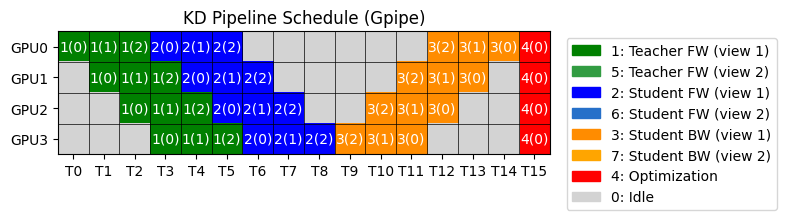

In [9]:
trans_grid_text = np.array(transpose(grid_text))
trans_grid_color = np.array(transpose(grid_color))
# print(trans_grid_color.shape)
cmap = colors.ListedColormap([
    'lightgray',       # 0 - Idle
    'green',         # 1 - Forward (T, View1) - Green
    'blue',            # 2 - Forward (S, View1) - Blue
    '#ff8c00',         # 3 - Backward (S, View1) - DarkOrange
    'red',             # 4 - Optimize
    '#329C42',         # 5 - Forward (T, View2) - SeaGreen
    '#2670C9',         # 6 - Forward (S, View2) - DodgerBlue
    'orange'          # 7 - Backward (S, View2) - orange
])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(12, 2))
plt.imshow(trans_grid_color, cmap=cmap, norm=norm)

# Annotate each grid
for i in range(n):
    for j in range(num_steps):
        if trans_grid_text[i][j] is not None:
            plt.text(j, i, trans_grid_text[i][j], ha='center', va='center', color='white', fontsize=10)

# Axis config and between-cell grid lines
plt.xticks(np.arange(num_steps), labels=[f'T{t}' for t in range(num_steps)])
plt.yticks(np.arange(n), labels=[f'GPU{j}' for j in range(n)])
plt.gca().set_xticks(np.arange(-0.5, num_steps, 1), minor=True)
plt.gca().set_yticks(np.arange(-0.5, n, 1), minor=True)
plt.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
plt.tick_params(which='minor', bottom=False, left=False)

# Updated legend
legend_elements = [
    patches.Patch(color='green', label='1: Teacher FW (view 1)'),
    patches.Patch(color='#329C42', label='5: Teacher FW (view 2)'),
    patches.Patch(color='blue', label='2: Student FW (view 1)'),
    patches.Patch(color='#2670C9', label='6: Student FW (view 2)'),
    patches.Patch(color='#ff8c00', label='3: Student BW (view 1)'),
    patches.Patch(color='orange', label='7: Student BW (view 2)'),
    patches.Patch(color='red', label='4: Optimization'),
    patches.Patch(color='lightgray', label='0: Idle')
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title("KD Pipeline Schedule (Gpipe)")
plt.tight_layout()
plt.show()

In [10]:
# 